In [ ]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [ ]:
#TODO replace the path with your path in drive
#This usually takes 10 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [ ]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [ ]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


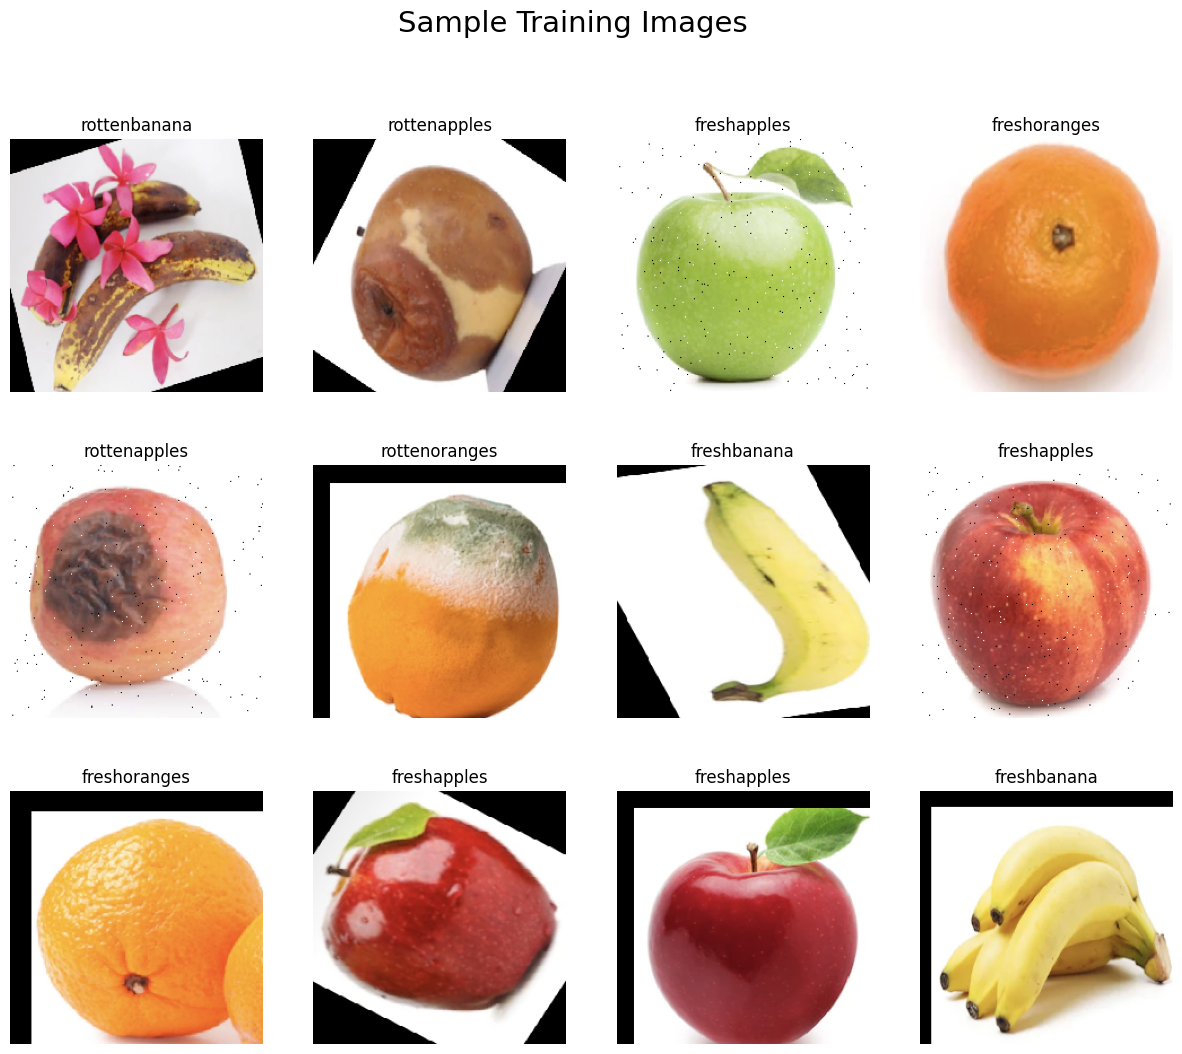

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [ ]:
from keras.applications.densenet import DenseNet201

In [ ]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [ ]:
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D

# Load DenseNet201 without top
base_model = DenseNet201(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(224, 224, 3))
)

# Freeze all layers in DenseNet201
for layer in base_model.layers:
    layer.trainable = False

# Add new custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(6, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=x)

In [ ]:

from keras.callbacks import LearningRateScheduler

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("densenet201.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,333,510 (69.94 MB)

 Trainable params: 11,526 (45.02 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [ ]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data=val_dataset,
    validation_steps = validationsteps
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1417']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7713 - loss: 0.7386
Epoch 1: val_loss improved from inf to 0.08677, saving model to densenet201.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 100s 305ms/step - accuracy: 0.7720 - loss: 0.7367 - val_accuracy: 1.0000 - val_loss: 0.0868 - learning_rate: 0.0010
Epoch 2/30
  1/187 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 1.0000 - loss: 0.0976

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate
  current = self.get_monitor_value(logs)


...

187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.9880 - loss: 0.0524 - val_accuracy: 1.0000 - val_loss: 0.0192 - learning_rate: 8.1451e-04
Epoch 6/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - accuracy: 0.9900 - loss: 0.0483
Epoch 6: val_loss did not improve from 0.01921
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9911 - loss: 0.0457 - val_accuracy: 1.0000 - val_loss: 0.0310 - learning_rate: 7.7378e-04
Epoch 7/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9906 - loss: 0.0411
Epoch 7: val_loss improved from 0.01921 to 0.01732, saving model to densenet201.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 199ms/step - accuracy: 0.9906 - loss: 0.0411 - val_accuracy: 1.0000 - val_loss: 0.0173 - learning_rate: 7.3509e-04
Epoch 8/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9949 - loss: 0.0303
Epoch 8: val_loss did not improve from 0.01732
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.9952 - loss: 0.0307 - val_accuracy: 1.0000 - val_loss: 0.0336 - learning_rate: 6.9834e-04
Epoch 9/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9974 - loss: 0.0279
Epoch 9: val_loss did not improve from 0.01732
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.9974 - loss: 0.0279 - val_accuracy: 1.0000 - val_loss: 0.0201 - learning_rate: 6.6342e-04
Epoch 10/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.9941 - loss: 0.0296
Epoch 10: val_loss did not improve from 0.01732
187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - accuracy: 0.9949 - loss: 0.0285 - val_accuracy: 0.9688 - val_loss: 0.0433 - learning_rate: 6.3025e-04

187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.9977 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 0.0058 - learning_rate: 5.6880e-04
Epoch 13/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9977 - loss: 0.0218
Epoch 13: val_loss did not improve from 0.00583
187/187 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - accuracy: 0.9977 - loss: 0.0218 - val_accuracy: 1.0000 - val_loss: 0.0072 - learning_rate: 5.4036e-04
Epoch 14/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9987 - loss: 0.0165
Epoch 14: val_loss did not improve from 0.00583
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.9986 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 0.0234 - learning_rate: 5.1334e-04
Epoch 15/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9993 - loss: 0.0151
Epoch 15: val_loss did not improve from 0.00583
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.9992 - loss: 0.0151 - val_accuracy: 1.0000 - val_loss: 0.0070 - learning_rate: 4.8767e

187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.9986 - loss: 0.0141 - val_accuracy: 1.0000 - val_loss: 0.0039 - learning_rate: 3.9721e-04
Epoch 20/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9993 - loss: 0.0122
Epoch 20: val_loss did not improve from 0.00387
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9993 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0092 - learning_rate: 3.7735e-04
Epoch 21/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9990 - loss: 0.0126
Epoch 21: val_loss did not improve from 0.00387
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - accuracy: 0.9990 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 0.0082 - learning_rate: 3.5849e-04
Epoch 22/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.9987 - loss: 0.0113
Epoch 22: val_loss did not improve from 0.00387
187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.9990 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0094 - learning_rate: 3.4056

187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.9990 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0037 - learning_rate: 2.3783e-04
Epoch 30/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9993 - loss: 0.0089
Epoch 30: val_loss did not improve from 0.00366
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.9993 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0088 - learning_rate: 2.2594e-04


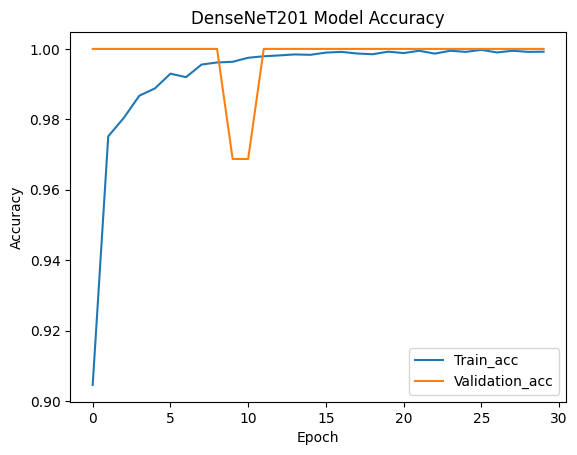

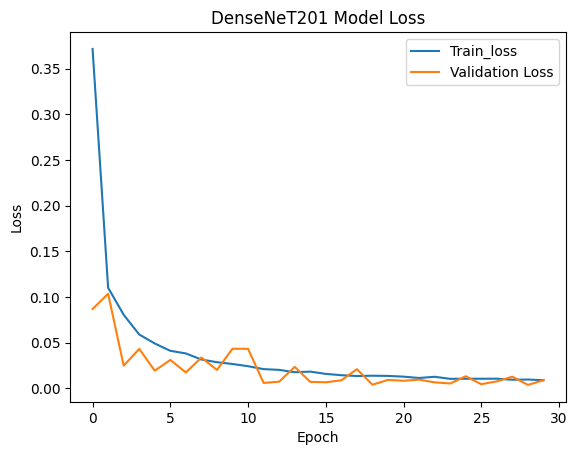

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('DenseNeT201 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('DenseNeT201 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.
2698/2698 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - accuracy: 0.9985 - loss: 0.0111
accuracy test:  0.997405469417572
loss test:  0.014431176707148552


In [ ]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1417']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step


In [ ]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

1
(1, 6)


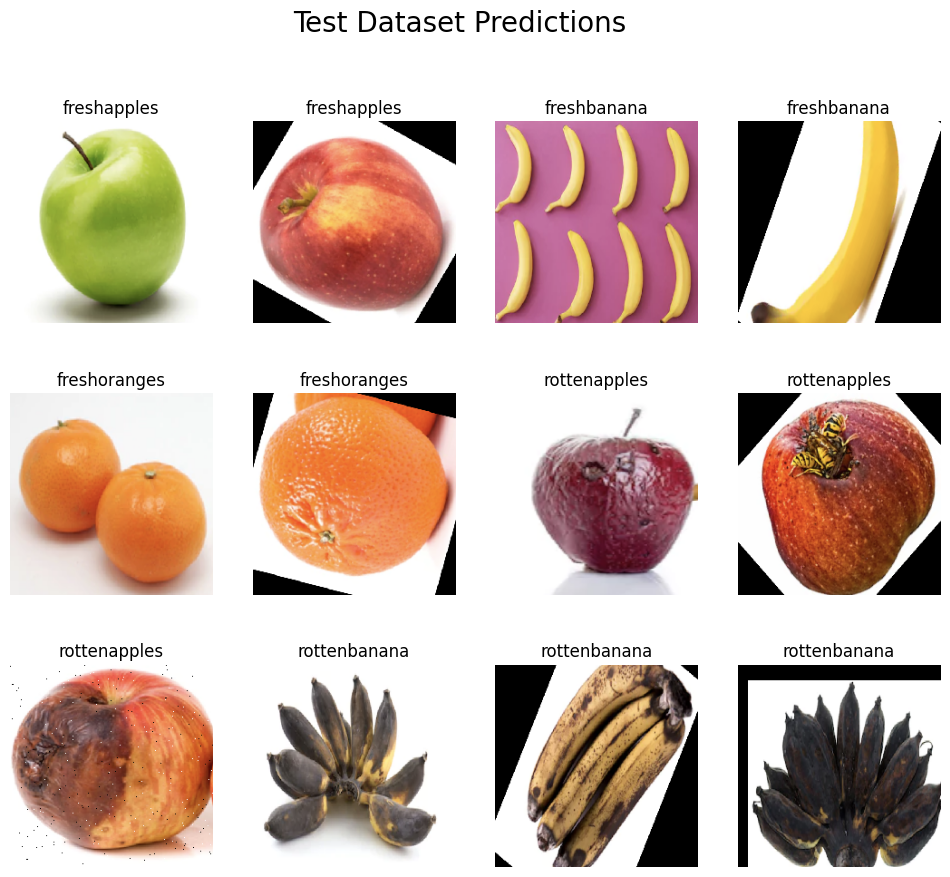

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [ ]:
!apt install graphviz # Install graphviz (Only needed when in local runtime)
!pip install pydot # Install pydot as well (only when in local runtime)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
#from keras.utils.vis_utils import plot_model
# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )

# tf.keras.utils.plot_model(
#     model,
#     to_file="model.png",
#     show_shapes=True,
#     show_layer_names=True,
#     expand_nested=False,
#     dpi=72
# )

In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 27.9 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [ ]:
test_steps_per_epoch = np.ceil(test_generator.samples / test_generator.batch_size)

# Convert test_steps_per_epoch to an integer
test_steps_per_epoch = int(test_steps_per_epoch)

In [ ]:
predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

2698/2698 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step


In [ ]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

               precision    recall  f1-score   support

  freshapples       0.99      1.00      0.99       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       1.00      1.00      1.00       388
 rottenapples       1.00      0.99      0.99       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       1.00      1.00      1.00       403

     accuracy                           1.00      2698
    macro avg       1.00      1.00      1.00      2698
 weighted avg       1.00      1.00      1.00      2698



In [ ]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

Confusion Matrix


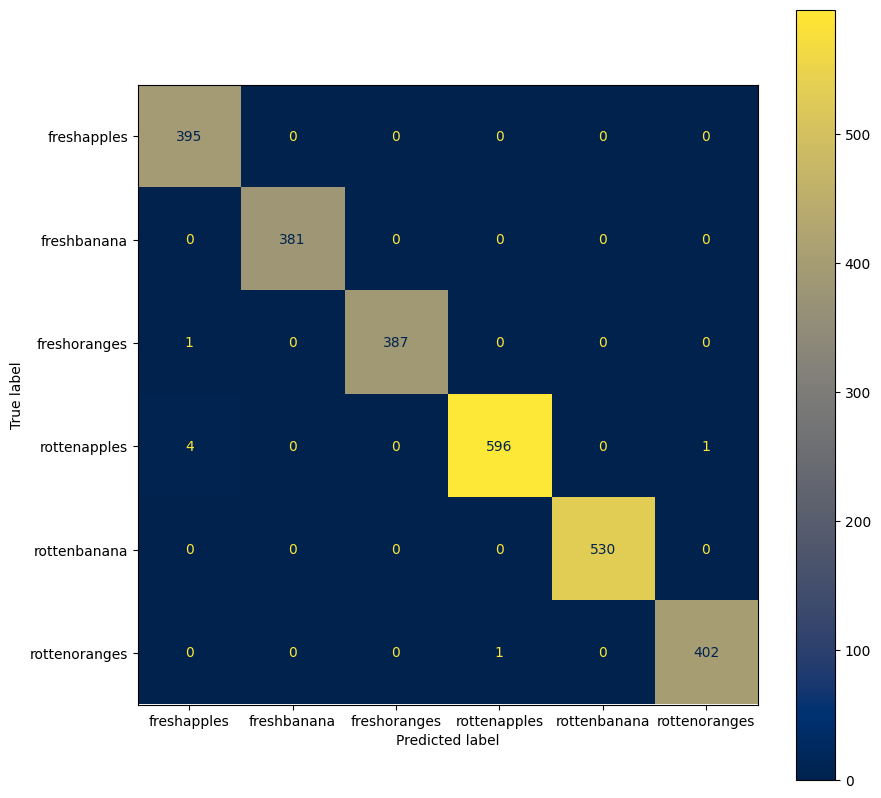

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")